/tmp/ipykernel_515/448141418.py:43: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training shape: (958, 60, 1)
Testing shape : (240, 60, 1)
Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 0.0421 - val_loss: 0.0181
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0016 - val_loss: 0.0063
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 8.4877e-04 - val_loss: 0.0037
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 7.2690e-04 - val_loss: 0.0012
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 6.8543e-04 - val_loss: 0.0027
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 5.8375e-04 - val_loss: 0.0017
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 5.4250e-04 - val_loss: 0.0014
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 5.6691e-04 - val_loss: 0.0013
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 5.2139e-04 - val_loss: 5.9932e-04
Epoch 10/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 4.7551e-04 - val_loss: 8.7684e-04
Epoch 11/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step

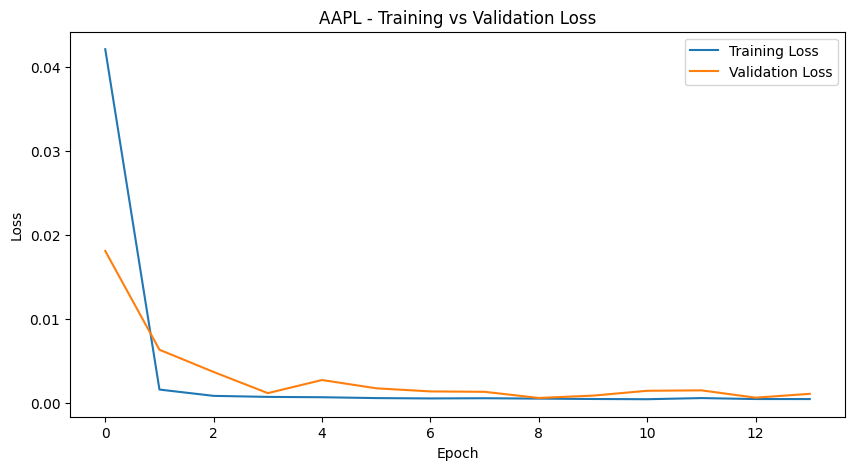

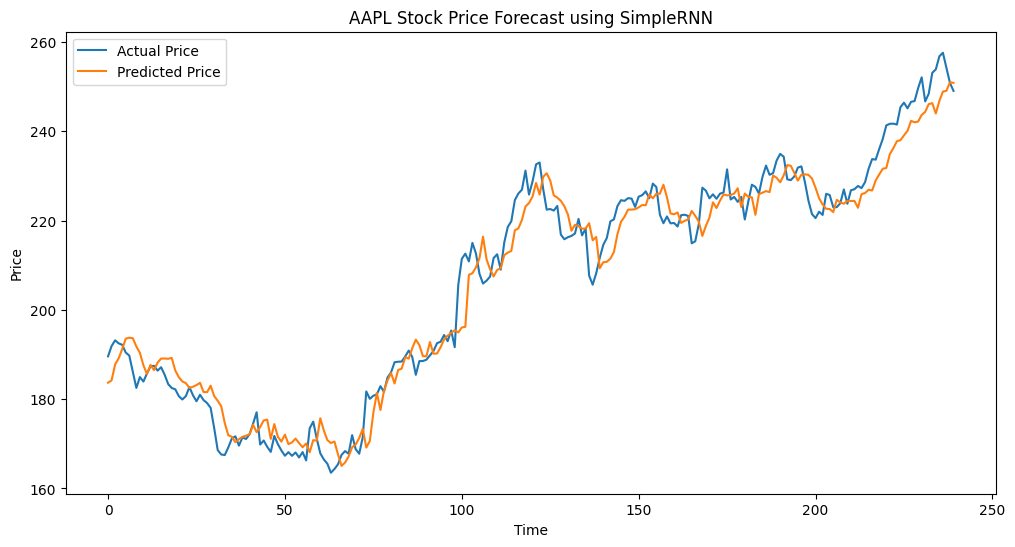

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step

Predicted next closing price for AAPL: 248.74


In [1]:
# Time Series Forecasting using SimpleRNN in TensorFlow

import sys
import subprocess
import importlib.util

# -------- Auto-install required packages --------
required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "tensorflow": "tensorflow",
    "yfinance": "yfinance"
}

for import_name, pip_name in required_packages.items():
    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])

# -------- Imports --------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.callbacks import EarlyStopping

# -------- User settings --------
ticker = "AAPL"          # Change stock symbol here
start_date = "2020-01-01"
end_date = "2025-01-01"
time_step = 60
epochs = 20
batch_size = 32

# -------- Download data --------
df = yf.download(ticker, start=start_date, end=end_date)

if df.empty:
    raise ValueError("No data downloaded. Check ticker symbol or internet connection.")

# Use Close price
data = df[["Close"]].copy()

# -------- Scale data --------
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# -------- Create sequences --------
def create_dataset(dataset, time_step=60):
    X, y = [], []
    for i in range(len(dataset) - time_step):
        X.append(dataset[i:i + time_step, 0])
        y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(y)

X, y = create_dataset(scaled_data, time_step)

# Reshape for RNN: [samples, time_steps, features]
X = X.reshape(X.shape[0], X.shape[1], 1)

# -------- Train-test split --------
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("Training shape:", X_train.shape)
print("Testing shape :", X_test.shape)

# -------- Build model --------
model = Sequential([
    SimpleRNN(50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    SimpleRNN(50),
    Dense(1)
])

model.compile(optimizer="adam", loss="mean_squared_error")

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# -------- Train model --------
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1,
    callbacks=[early_stop]
)

# -------- Predict --------
predictions = model.predict(X_test)

# Convert back to original scale
predictions_unscaled = scaler.inverse_transform(predictions)
y_test_unscaled = scaler.inverse_transform(y_test.reshape(-1, 1))

# -------- Evaluation --------
mse = mean_squared_error(y_test_unscaled, predictions_unscaled)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_unscaled, predictions_unscaled)

print("\nEvaluation Metrics")
print("------------------")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)

# -------- Plot training loss --------
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title(f"{ticker} - Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# -------- Plot actual vs predicted --------
plt.figure(figsize=(12, 6))
plt.plot(y_test_unscaled, label="Actual Price")
plt.plot(predictions_unscaled, label="Predicted Price")
plt.title(f"{ticker} Stock Price Forecast using SimpleRNN")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

# -------- Next-day prediction --------
last_60_days = scaled_data[-time_step:]
last_60_days = last_60_days.reshape(1, time_step, 1)

next_day_scaled = model.predict(last_60_days)
next_day_price = scaler.inverse_transform(next_day_scaled)

print(f"\nPredicted next closing price for {ticker}: {next_day_price[0][0]:.2f}")